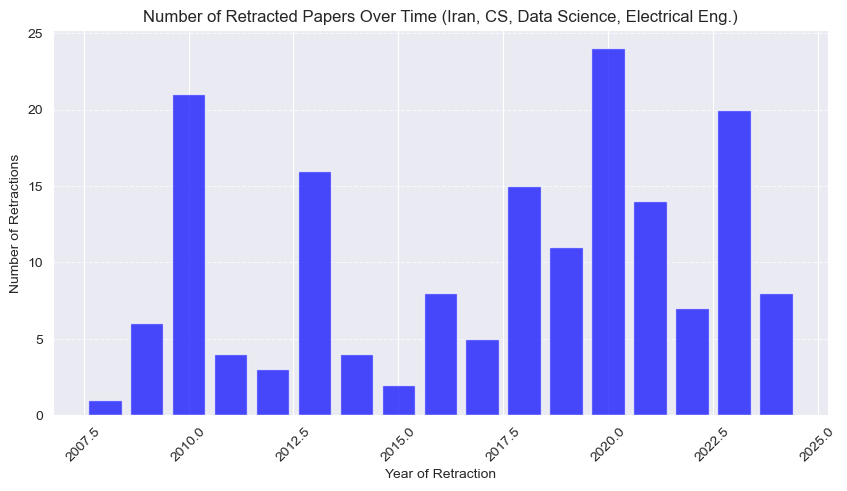

count    169.000000
mean       2.863905
std        3.321888
min        0.000000
25%        0.000000
50%        2.000000
75%        4.000000
max       15.000000
Name: RetractionLag, dtype: float64

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec.csv")

# Convert date columns to datetime format
df["RetractionDate"] = pd.to_datetime(df["RetractionDate"], errors='coerce')
df["OriginalPaperDate"] = pd.to_datetime(df["OriginalPaperDate"], errors='coerce')

# Extract year of retraction and original publication
df["RetractionYear"] = df["RetractionDate"].dt.year
df["OriginalYear"] = df["OriginalPaperDate"].dt.year

# Calculate retraction time lag (years between publication and retraction)
df["RetractionLag"] = df["RetractionYear"] - df["OriginalYear"]

# Count number of retractions per year
retractions_per_year = df["RetractionYear"].value_counts().sort_index()

# Plot number of retractions per year
plt.figure(figsize=(10, 5))
plt.bar(retractions_per_year.index, retractions_per_year.values, color="blue", alpha=0.7)
plt.xlabel("Year of Retraction")
plt.ylabel("Number of Retractions")
plt.title("Number of Retracted Papers Over Time (Iran, CS, Data Science, Electrical Eng.)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Display retraction time lag statistics
df["RetractionLag"].describe()


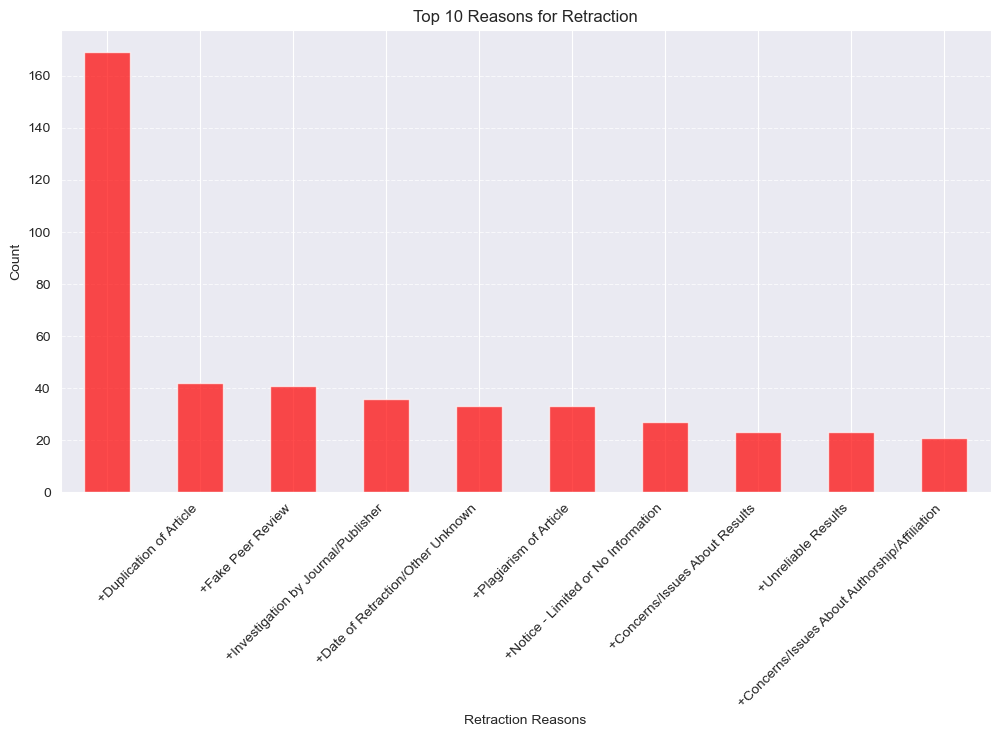

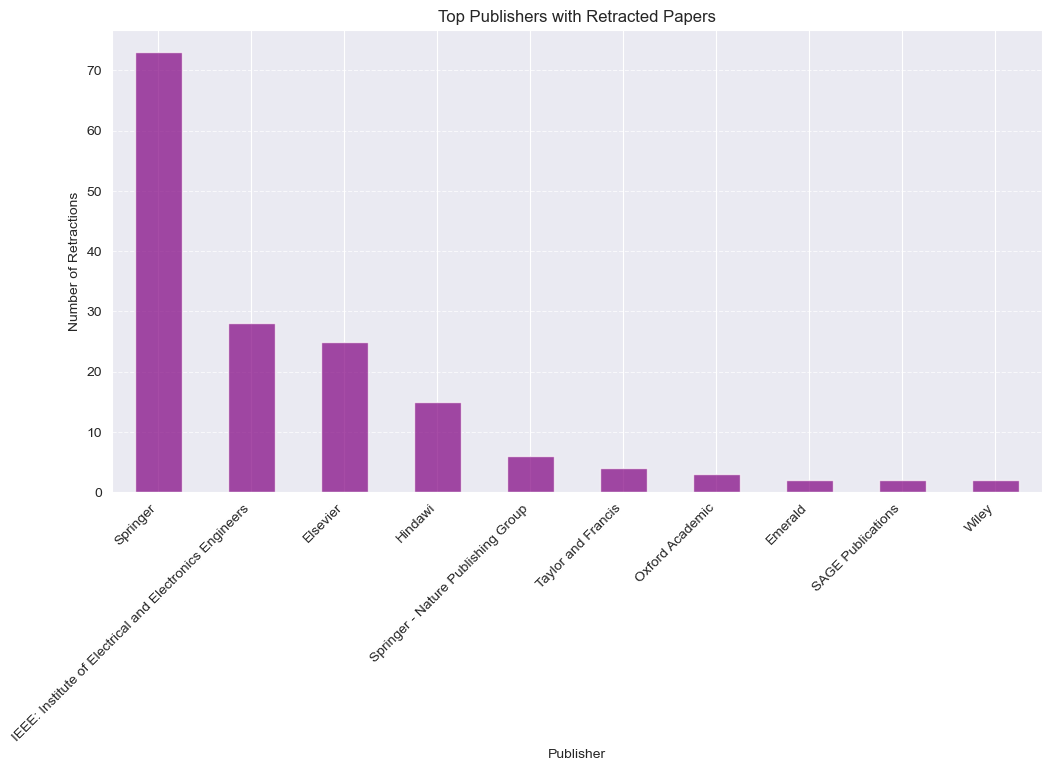

In [5]:
# Count occurrences of retraction reasons
retraction_reasons = df["Reason"].str.split(";", expand=True).stack().str.strip().value_counts()

# Plot reasons for retractions
plt.figure(figsize=(12, 6))
retraction_reasons[:10].plot(kind="bar", color="red", alpha=0.7)
plt.xlabel("Retraction Reasons")
plt.ylabel("Count")
plt.title("Top 10 Reasons for Retraction")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Count occurrences of publishers
publisher_counts = df["Publisher"].value_counts()

# Plot publishers involved in retractions
plt.figure(figsize=(12, 6))
publisher_counts[:10].plot(kind="bar", color="purple", alpha=0.7)
plt.xlabel("Publisher")
plt.ylabel("Number of Retractions")
plt.title("Top Publishers with Retracted Papers")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [6]:
import networkx as nx

# Construct a citation network (if citation data exists)
# Using RetractionDOI and OriginalPaperDOI to build citation links

citation_edges = df[["OriginalPaperDOI", "RetractionDOI"]].dropna().values

# Create a directed graph
G = nx.DiGraph()
G.add_edges_from(citation_edges)

# Compute basic network statistics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
avg_degree = sum(dict(G.degree()).values()) / num_nodes if num_nodes > 0 else 0

# Detect communities using modularity-based clustering
from networkx.algorithms.community import greedy_modularity_communities

if num_nodes > 0:
    communities = list(greedy_modularity_communities(G))
    num_communities = len(communities)
else:
    num_communities = 0

# Display network statistics
network_stats = {
    "Number of Nodes (Papers)": num_nodes,
    "Number of Edges (Citations)": num_edges,
    "Network Density": round(density, 4),
    "Average Degree (Connections per Paper)": round(avg_degree, 2),
    "Number of Communities": num_communities,
}

network_stats

{'Number of Nodes (Papers)': 259,
 'Number of Edges (Citations)': 154,
 'Network Density': 0.0023,
 'Average Degree (Connections per Paper)': 1.19,
 'Number of Communities': 148}

In [7]:
# Calculate self-citation rate
self_citations = 0
total_citations = 0

for source, target in G.edges():
    source_authors = df[df["OriginalPaperDOI"] == source]["Author"].values
    target_authors = df[df["RetractionDOI"] == target]["Author"].values

    if len(source_authors) > 0 and len(target_authors) > 0:
        if any(author in target_authors[0] for author in source_authors[0].split(";")):
            self_citations += 1
        total_citations += 1

# Compute self-citation percentage
self_citation_rate = (self_citations / total_citations) * 100 if total_citations > 0 else 0

self_citation_rate

98.7012987012987

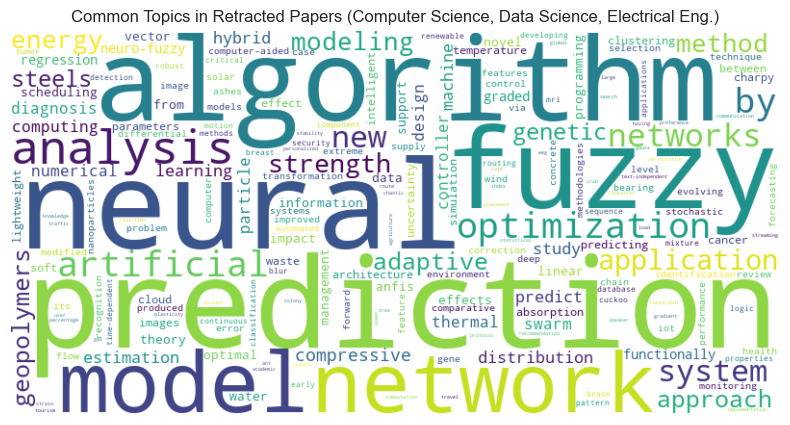

[('prediction', 26),
 ('neural', 25),
 ('algorithm', 22),
 ('fuzzy', 20),
 ('model', 19),
 ('network', 18),
 ('analysis', 17),
 ('optimization', 17),
 ('artificial', 17),
 ('by', 16)]

In [8]:
from collections import Counter
from wordcloud import WordCloud

# Extract keywords from the titles of retracted papers
all_titles = " ".join(df["Title"].dropna()).lower()

# Tokenize and count word frequencies (excluding common stopwords)
stopwords = {"the", "of", "and", "in", "for", "on", "with", "a", "to", "an", "using", "based"}
words = [word for word in all_titles.split() if word not in stopwords]
word_counts = Counter(words)

# Generate a word cloud for visualization
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_counts)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Topics in Retracted Papers (Computer Science, Data Science, Electrical Eng.)")
plt.show()

# Display top 10 most common keywords
word_counts.most_common(10)

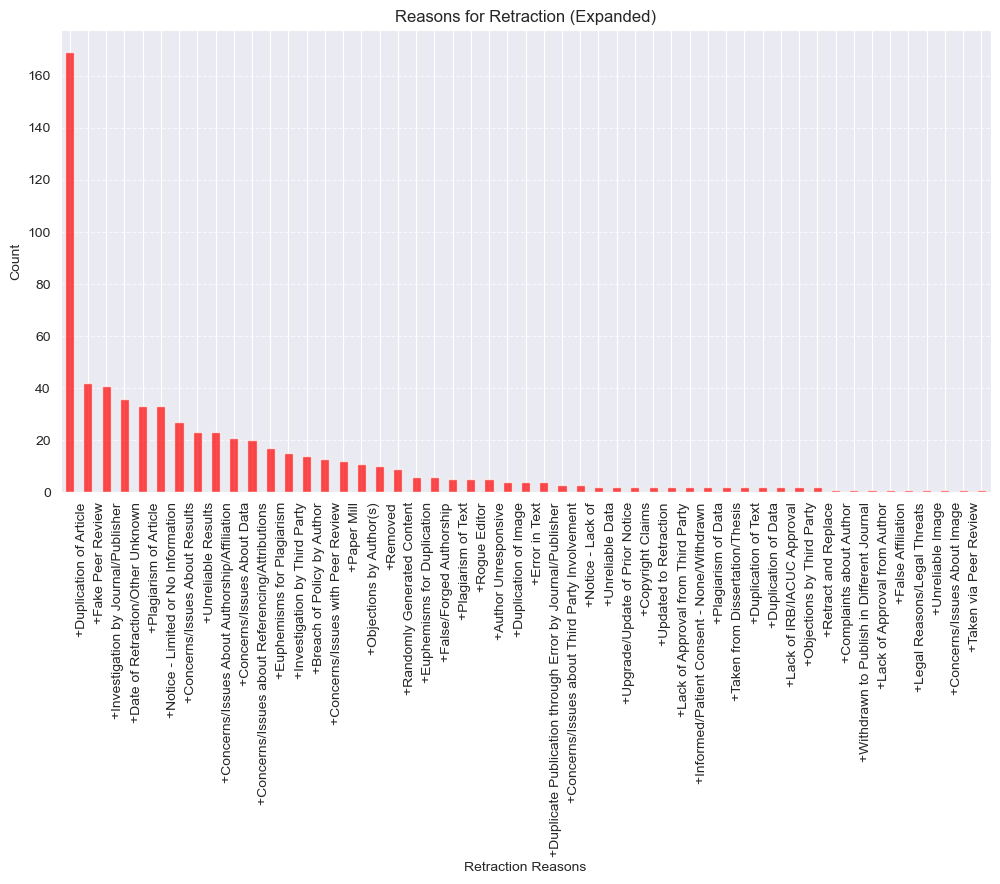

In [10]:
# Re-process retraction reasons with multiple entries per row

# Split reasons into multiple rows and count occurrences
retraction_reasons_expanded = df["Reason"].str.split(";", expand=True).stack().str.strip()
retraction_reasons_counts = retraction_reasons_expanded.value_counts()

# Plot reasons for retractions with improved labeling
plt.figure(figsize=(12, 6))
retraction_reasons_counts.plot(kind="bar", color="red", alpha=0.7)
plt.xlabel("Retraction Reasons")
plt.ylabel("Count")
plt.title("Reasons for Retraction (Expanded)")
plt.xticks(rotation=45, ha="right")

# Ensure left-most bar has a proper label
plt.xticks(ticks=range(len(retraction_reasons_counts)), labels=retraction_reasons_counts.index, rotation=90, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

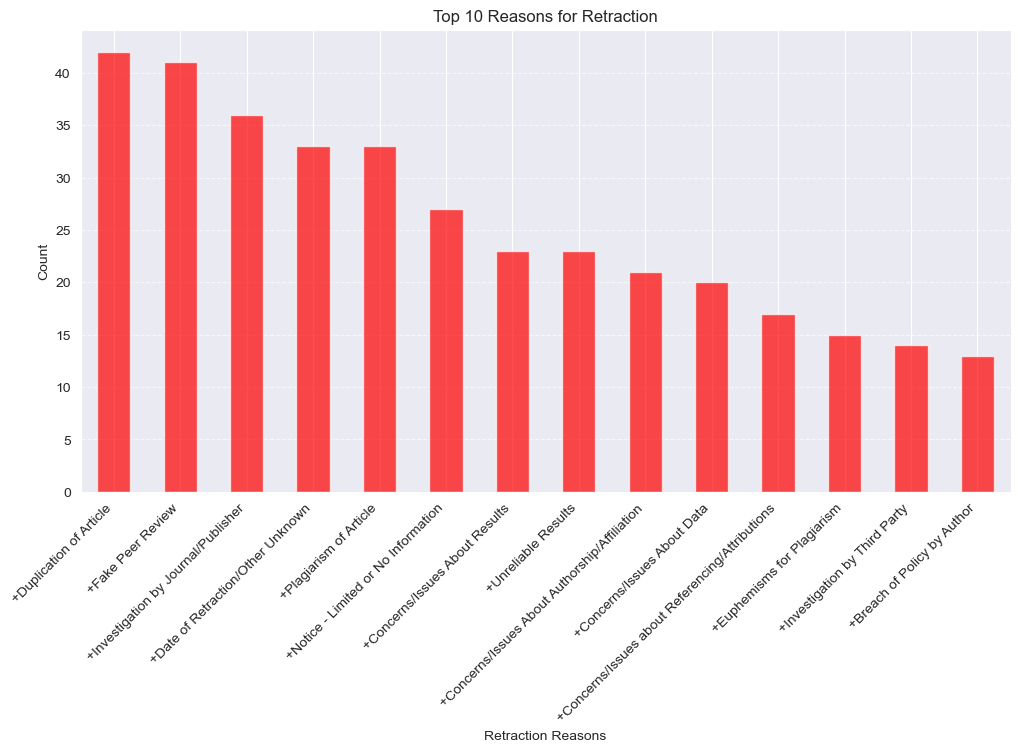

In [16]:
# Select top 10 most common retraction reasons
top_10_retraction_reasons = retraction_reasons_counts[1:15]

# Plot top 10 retraction reasons
plt.figure(figsize=(12, 6))
top_10_retraction_reasons.plot(kind="bar", color="red", alpha=0.7)
plt.xlabel("Retraction Reasons")
plt.ylabel("Count")
plt.title("Top 10 Reasons for Retraction")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [15]:
top_10_retraction_reasons

+Duplication of Article                          42
+Fake Peer Review                                41
+Investigation by Journal/Publisher              36
+Date of Retraction/Other Unknown                33
+Plagiarism of Article                           33
+Notice - Limited or No Information              27
+Concerns/Issues About Results                   23
+Unreliable Results                              23
+Concerns/Issues About Authorship/Affiliation    21
Name: count, dtype: int64

In [17]:
import pandas as pd
import networkx as nx

# Load the dataset
file_path = r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec.csv"  # Change this to your actual file path
df = pd.read_csv(file_path)

# Create a directed graph
G = nx.DiGraph()

# Add nodes (articles) using their DOI or Record ID
for _, row in df.iterrows():
    article_id = row["RetractionDOI"] if pd.notna(row["RetractionDOI"]) else row["Record ID"]
    G.add_node(article_id, title=row["Title"], author=row["Author"], year=row["RetractionYear"])

# Add edges (citations between retracted articles)
for _, row in df.iterrows():
    citing_paper = row["RetractionDOI"]
    cited_paper = row["OriginalPaperDOI"]

    if pd.notna(citing_paper) and pd.notna(cited_paper):
        G.add_edge(citing_paper, cited_paper)

# Output GML file for Gephi
output_gml_path = "retracted_citation_network.gml"
nx.write_gml(G, output_gml_path)

print(f"GML file saved as {output_gml_path}. You can now import it into Gephi.")

KeyError: 'RetractionYear'

In [18]:
# The 'RetractionDate' column contains date values in string format.
# We'll extract the year from these dates and then group by year to count retractions.
data = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\finalTopic\Merged_Retraction___Citation_Data.csv")
# Convert the 'RetractionDate' column to datetime format
data['RetractionDate'] = pd.to_datetime(data['RetractionDate'], errors='coerce')

# Extract the year from the dates
data['RetractionYear'] = data['RetractionDate'].dt.year

# Group by year and count the number of retractions
retraction_trends = data.groupby('RetractionYear').size().reset_index(name='Count')

# Sort by year for proper visualization
retraction_trends = retraction_trends.sort_values(by='RetractionYear')

# Display the trends to ensure data is correct
retraction_trends.head()

,RetractionYear,Count
0,2008,1
1,2009,6
2,2010,21
3,2011,4
4,2012,3


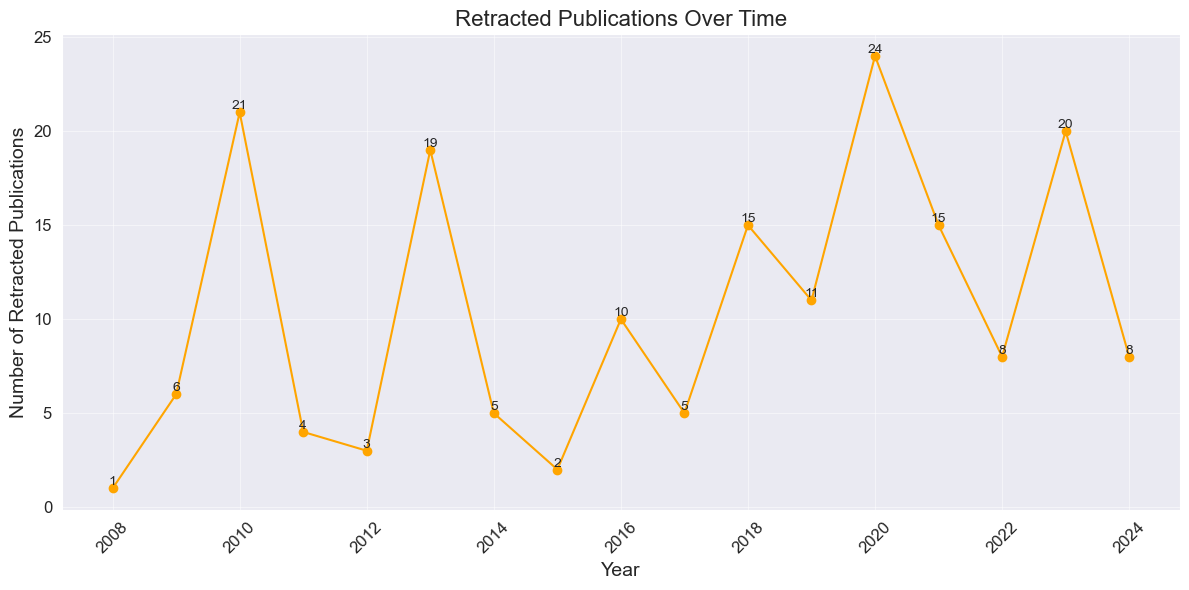

In [19]:
import matplotlib.pyplot as plt

# Generate the retraction trends chart with numbers annotated on each year

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(retraction_trends['RetractionYear'], retraction_trends['Count'], marker='o', linestyle='-', color='orange')
plt.title("Retracted Publications Over Time", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Retracted Publications", fontsize=14)
plt.grid(True, alpha=0.5)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

# Annotate each point with the count value
for _, row in retraction_trends.iterrows():
    plt.text(row['RetractionYear'], row['Count'], str(row['Count']), fontsize=10, ha='center', va='bottom')

plt.tight_layout()
plt.show()

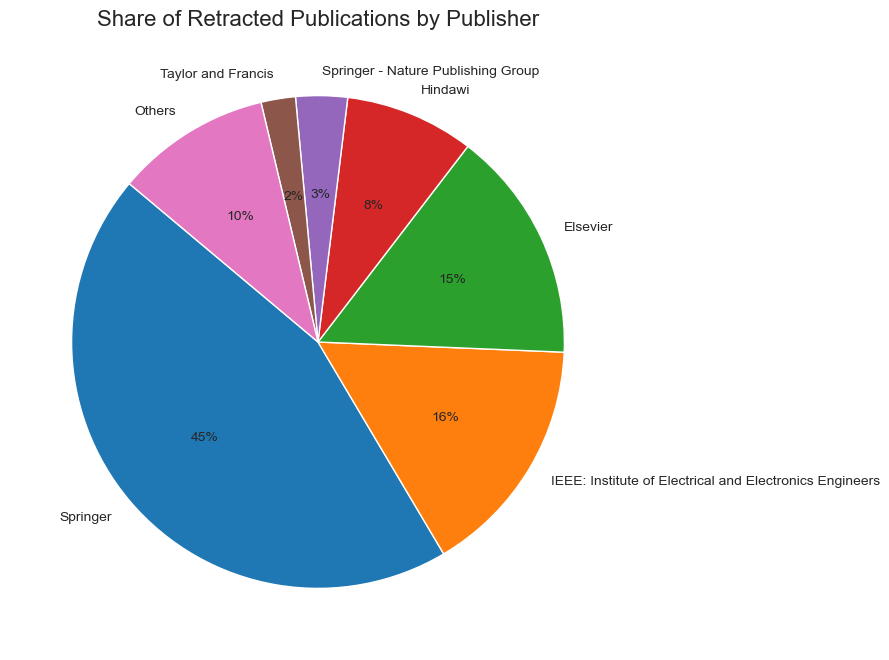

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by the 'Publisher' column and calculate the proportion of retracted publications for each publisher
publisher_counts = data['Publisher'].value_counts(normalize=True) * 100

# Select the top publishers and group others into an "Others" category
threshold = 2  # Publishers with less than 2% will be grouped into "Others"
top_publishers = publisher_counts[publisher_counts >= threshold]
others = pd.Series({'Others': publisher_counts[publisher_counts < threshold].sum()})
publisher_counts = pd.concat([top_publishers, others])

# Prepare data for the pie chart
labels = publisher_counts.index
sizes = publisher_counts.values

# Plot the pie chart
plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=labels, autopct='%1.0f%%', startangle=140, colors=plt.cm.tab10.colors)
plt.title("Share of Retracted Publications by Publisher", fontsize=16)
plt.show()

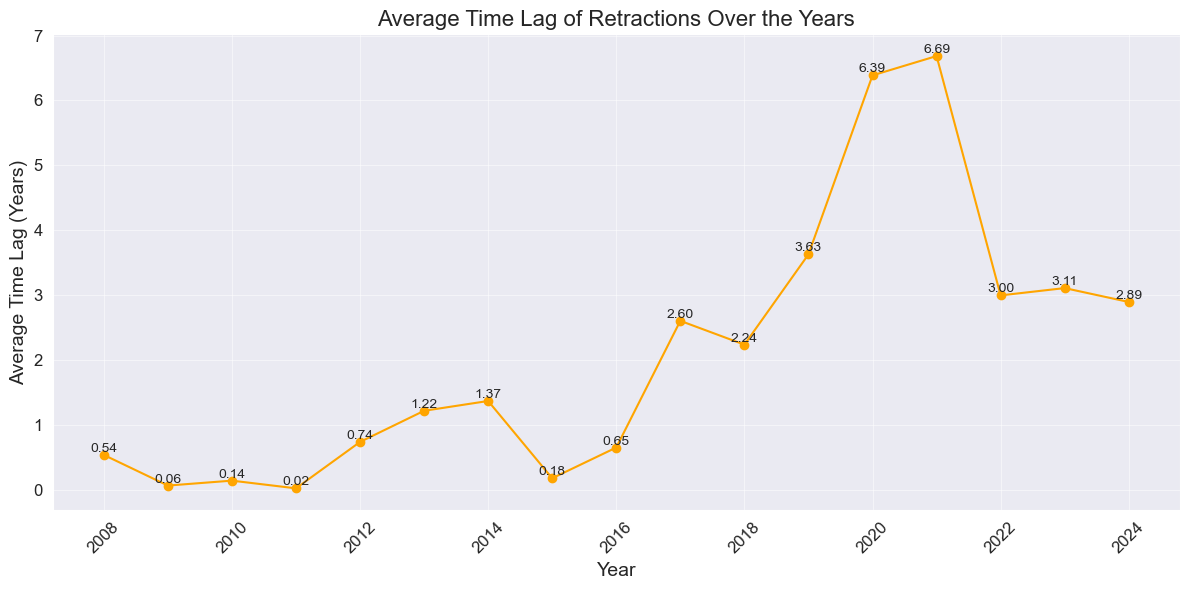

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert the date columns to datetime format
data['OriginalPaperDate'] = pd.to_datetime(data['OriginalPaperDate'], errors='coerce')
data['RetractionDate'] = pd.to_datetime(data['RetractionDate'], errors='coerce')

# Calculate the time lag in years
data['TimeLag'] = (data['RetractionDate'] - data['OriginalPaperDate']).dt.days / 365.25

# Group by year of retraction and calculate the average time lag
data['RetractionYear'] = data['RetractionDate'].dt.year
avg_time_lag = data.groupby('RetractionYear')['TimeLag'].mean().reset_index(name='AverageTimeLag')

# Drop NaN values to ensure clean plotting
avg_time_lag = avg_time_lag.dropna()

# Plot the average time lag per year
plt.figure(figsize=(12, 6))
plt.plot(avg_time_lag['RetractionYear'], avg_time_lag['AverageTimeLag'], marker='o', linestyle='-', color='orange')
plt.title("Average Time Lag of Retractions Over the Years", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Average Time Lag (Years)", fontsize=14)
plt.grid(True, alpha=0.5)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

# Annotate each point with the average time lag value
for _, row in avg_time_lag.iterrows():
    plt.text(row['RetractionYear'], row['AverageTimeLag'], f"{row['AverageTimeLag']:.2f}", fontsize=10, ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [24]:
# Convert the date columns to datetime format
data['OriginalPaperDate']

0     2021-10-27
1     2021-08-31
2     2021-10-28
3     2022-03-21
4     2021-10-18
         ...    
172   2016-07-01
173   2013-06-18
174   2009-04-17
175   2010-05-01
176   2012-07-15
Name: OriginalPaperDate, Length: 177, dtype: datetime64[ns]

In [25]:
data['RetractionDate']

0     2023-11-01
1     2023-11-29
2     2023-12-06
3     2023-12-06
4     2023-12-06
         ...    
172   2016-12-27
173   2014-05-26
174   2009-07-21
175   2013-01-01
176   2013-03-01
Name: RetractionDate, Length: 177, dtype: datetime64[ns]

In [26]:
data['TimeLag']

0      2.012320
1      2.245038
2      2.105407
3      1.711157
4      2.132786
         ...   
172    0.490075
173    0.936345
174    0.260096
175    2.672142
176    0.626968
Name: TimeLag, Length: 177, dtype: float64

<Figure size 1400x800 with 0 Axes>

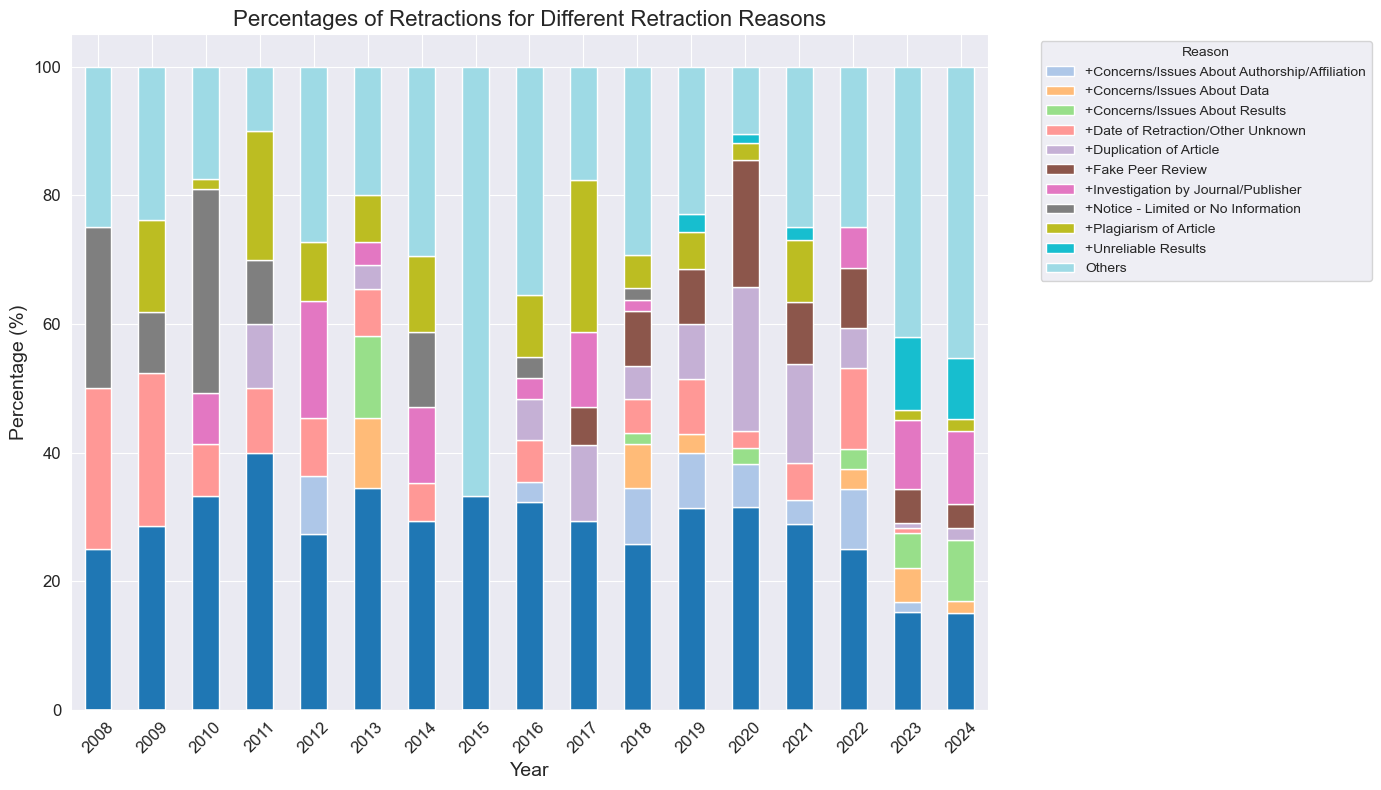

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Split the "Reason" field into multiple rows to handle multiple reasons per retraction
reasons_data = data.assign(Reason=data['Reason'].str.split(';')).explode('Reason')

# Strip any leading/trailing whitespace and filter out empty values
reasons_data['Reason'] = reasons_data['Reason'].str.strip()
reasons_data = reasons_data[reasons_data['Reason'].notna()]

# Group by reason and count occurrences to identify the top 11 reasons
top_reasons = reasons_data['Reason'].value_counts().head(11)
top_reasons_list = top_reasons.index.tolist()

# Replace less frequent reasons with "Others"
reasons_data['Reason'] = reasons_data['Reason'].apply(
    lambda x: x if x in top_reasons_list else 'Others'
)

# Group by year and reason to calculate percentages
reasons_by_year = reasons_data.groupby(['RetractionYear', 'Reason']).size().unstack(fill_value=0)
reasons_by_year_percentage = reasons_by_year.div(reasons_by_year.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart
plt.figure(figsize=(14, 8))
reasons_by_year_percentage.plot(kind='bar', stacked=True, colormap='tab20', figsize=(14, 8))
plt.title("Percentages of Retractions for Different Retraction Reasons", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)
plt.legend(title="Reason", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()